In [1]:
%pip install -e ..

Obtaining file:///Users/pratikeliasjacob/Documents/Projects/simple-transformer
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for simple-transformer (pyproject.toml) ... done
  Created wheel for simple-transformer: filename=simple_transformer-0.1.0-0.editable-py3-none-any.whl size=2107 sha256=710b95b80ee0667b1e6fb33bee96d184f9b76f9f29be33872ed602467247af8c
  Stored in directory: /private/var/folders/qn/79klx_zs0m1fqrh1q4c5ql_00000gn/T/pip-ephem-wheel-cache-6vft3okj/wheels/de/d4/87/c813e0cb6465938cfd1c4350e8aa954bcfb9b50edc775763b4
Successfully built simple-transformer
  Attempting uninstall: simple-transformer
    Found existing installation: simple-transformer 0.1.0
    Uninstalling simple-transformer-0.1.0:
      Successfully uninstalled simple-transformer-0.1.0
Note: you may need to restart the kernel to 

In [2]:
from dataclasses import replace

import matplotlib.pyplot as plt
import torch

from simple_transformer.config import local_training_config, small_model_config
from simple_transformer.data import AdditionTokenizer, make_addition_dataloader
from simple_transformer.model import SimpleTransformerLM, count_parameters
from simple_transformer.train import fit, make_train_val_loaders

Matplotlib is building the font cache; this may take a moment.


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(torch.__version__)
print(device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.12.0
cpu


In [4]:
custom_examples = [
    "1+2=",
    "7+8=",
    "12+3=",
    "45+54=",
    "99+1=",
    "20+30=",
    "88+11=",
    "10+5=",
]

for example in custom_examples:
    print(example)

1+2=
7+8=
12+3=
45+54=
99+1=
20+30=
88+11=
10+5=


In [5]:
loader, tokenizer = make_addition_dataloader(
    num_examples=8,
    max_digits=2,
    batch_size=4,
    seed=42,
    shuffle=False,
)

batch = next(iter(loader))
print(batch["input_ids"].shape, batch["labels"].shape)
print(tokenizer.decode(batch["input_ids"][0]))

torch.Size([4, 9]) torch.Size([4, 9])
81+14=95


In [6]:
def show_generations(model, tokenizer, examples):
    model.eval()
    prompt_ids = [tokenizer.encode(example) for example in examples]
    generated_ids = model.generate_batch(
        prompt_ids,
        eos_token_id=tokenizer.eos_token_id,
    )

    for prompt, output_ids in zip(examples, generated_ids):
        print(f"{prompt:>8} -> {tokenizer.decode(output_ids)}")

In [7]:
train_config = replace(
    local_training_config(max_digits=2, device=device),
    train_examples=4096,
    val_examples=512,
    batch_size=64,
    epochs=8,
    warmup_steps=10,
)

model_config = small_model_config(
    max_digits=train_config.max_digits,
    device=train_config.device,
)
model = SimpleTransformerLM(model_config)
train_loader, val_loader, tokenizer = make_train_val_loaders(train_config)

print(f"parameters: {count_parameters(model):,}")
print(f"force flash: {model_config.force_flash}")
print(f"train batches: {len(train_loader)}, validation batches: {len(val_loader)}")
print("Before training:")
show_generations(model, tokenizer, custom_examples)

parameters: 1,068,160
force flash: False
train batches: 64, validation batches: 8
Before training:
    1+2= -> 1+2=111111
    7+8= -> 7+8=111111
   12+3= -> 12+3=11111
  45+54= -> 45+54=====
   99+1= -> 99+1==++++
  20+30= -> 20+30=====
  88+11= -> 88+11=1111
   10+5= -> 10+5=44444


In [8]:
def print_epoch(epoch, train, validation):
    print(
        f"epoch {epoch:02d} | "
        f"train loss {train.loss:.4f} acc {train.accuracy:.3f} | "
        f"val loss {validation.loss:.4f} acc {validation.accuracy:.3f} | "
        f"lr {train.learning_rate:.2e}"
    )

history = fit(
    model,
    train_loader,
    val_loader,
    train_config,
    on_epoch=print_epoch,
)

epoch 01 | train loss 1.9967 acc 0.387 | val loss 1.6645 acc 0.454 | lr 2.92e-04
epoch 02 | train loss 1.5619 acc 0.461 | val loss 1.5018 acc 0.459 | lr 2.65e-04
epoch 03 | train loss 1.4493 acc 0.469 | val loss 1.4249 acc 0.475 | lr 2.21e-04
epoch 04 | train loss 1.3620 acc 0.500 | val loss 1.3635 acc 0.494 | lr 1.69e-04
epoch 05 | train loss 1.3105 acc 0.522 | val loss 1.3153 acc 0.517 | lr 1.16e-04
epoch 06 | train loss 1.2665 acc 0.546 | val loss 1.2750 acc 0.548 | lr 7.10e-05
epoch 07 | train loss 1.2309 acc 0.563 | val loss 1.2457 acc 0.564 | lr 4.07e-05
epoch 08 | train loss 1.1958 acc 0.584 | val loss 1.2227 acc 0.580 | lr 3.00e-05


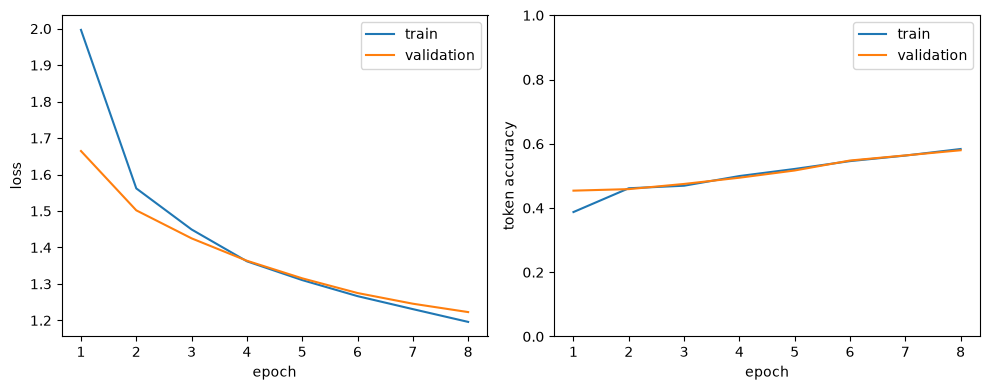

In [9]:
epochs = range(1, len(history.train) + 1)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, [metrics.loss for metrics in history.train], label="train")
plt.plot(epochs, [metrics.loss for metrics in history.validation], label="validation")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, [metrics.accuracy for metrics in history.train], label="train")
plt.plot(epochs, [metrics.accuracy for metrics in history.validation], label="validation")
plt.xlabel("epoch")
plt.ylabel("token accuracy")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

In [10]:
print("After training:")
show_generations(model, tokenizer, custom_examples)

final_train = history.train[-1]
final_validation = history.validation[-1]
print(
    f"final train loss={final_train.loss:.4f}, "
    f"train acc={final_train.accuracy:.3f}, "
    f"val loss={final_validation.loss:.4f}, "
    f"val acc={final_validation.accuracy:.3f}"
)

After training:
    1+2= -> 1+2=1
    7+8= -> 7+8=10
   12+3= -> 12+3=21
  45+54= -> 45+54=99
   99+1= -> 99+1=91
  20+30= -> 20+30=53
  88+11= -> 88+11=100
   10+5= -> 10+5=10
final train loss=1.1958, train acc=0.584, val loss=1.2227, val acc=0.580
